# Phase Locked Loop

## Simple PLL Example

PLL is used essentially to build a feedback loop that forces a local oscillator to match the phase and frequency of an incoming reference signal.

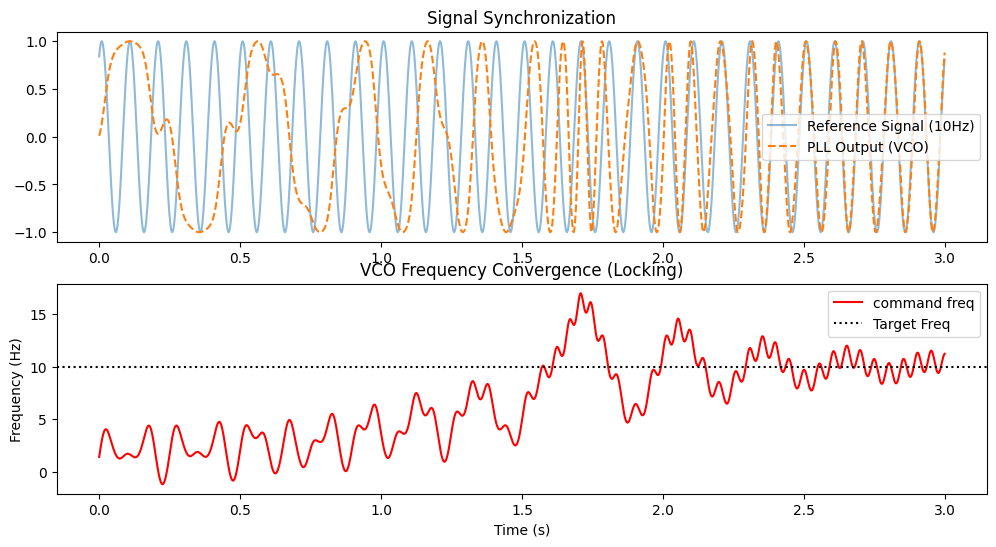

In [35]:
## Simple PLL to synchronize 2 sin waves

import numpy as np
import matplotlib.pyplot as plt

def simulate_pll(ref_freq, base_freq, fs, duration):
    t = np.arange(0, duration, 1/fs) # compute the time step based on sampling rate fs
    n = len(t)                       # compute sample number
    
    # Signal containers
    ref_phase = 1.0 # add a phase to the reference signal
    ref_sig = np.sin(2 * np.pi * ref_freq * t + ref_phase) # compute the reference signal r = sin(2*pi*f*t + phi)

    # log data for plot
    vco_sig = np.zeros(n) # vco signal data
    cmd_freq = np.zeros(n)
    errors = np.zeros(n)
    
    # PI Controller gains (Tuning these is key!), bigger the values, faster convergence
    Kp = 1.5
    Ki = 0.15
    
    # Initial states
    current_phase = 0.0
    integral_error = 0.0

    for i in range(n):
        # 1. Phase Detector (Multiplier + implicit Low Pass)
        # We multiply the incoming signal by the local signal
        error = ref_sig[i] * np.cos(current_phase) # Quadrature detection
        
        # 2. Loop Filter (PI Controller)
        integral_error += error
        phase_control = (Kp * error) + (Ki * integral_error)
        
        # 3. VCO (Update phase)
        # The freq is the base freq + the correction from the loop filter
        current_phase += 2 * np.pi * phase_control / fs

        # log the data for plot
        vco_sig[i] = np.sin(current_phase)
        cmd_freq[i] = phase_control
        errors[i] = error
        
    return t, ref_sig, vco_sig, cmd_freq, errors

# Parameters
fs = 1000          # Sampling frequency (Hz)
ref_f = 10.        # Target frequency (Hz)
base_f = 1.        # Starting local frequency (Hz)
duration = 3.0     # Seconds

t, ref, vco, freqs, errors = simulate_pll(ref_f, base_f, fs, duration)

# Plotting results
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, ref, label='Reference Signal (10Hz)', alpha=0.5)
plt.plot(t, vco, label='PLL Output (VCO)', linestyle='--')
plt.title("Signal Synchronization")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, freqs, color='red', label='command freq')
plt.axhline(y=ref_f, color='black', linestyle=':', label='Target Freq')
plt.title("VCO Frequency Convergence (Locking)")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.legend()

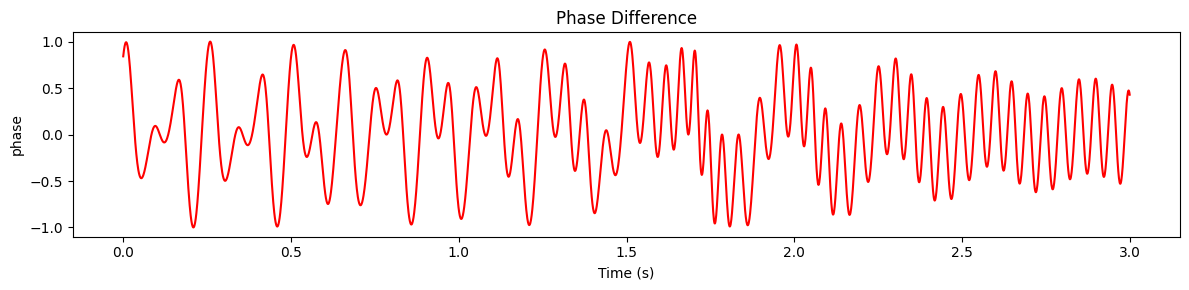

In [36]:
plt.figure(figsize=(12, 3))
plt.plot(t, errors, color='red')
plt.title("Phase Difference")
plt.ylabel("phase")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

# Time Difference

For step 3, since the simple time difference is always positive, the control output increases as well, which leads to an explosive output frequency.

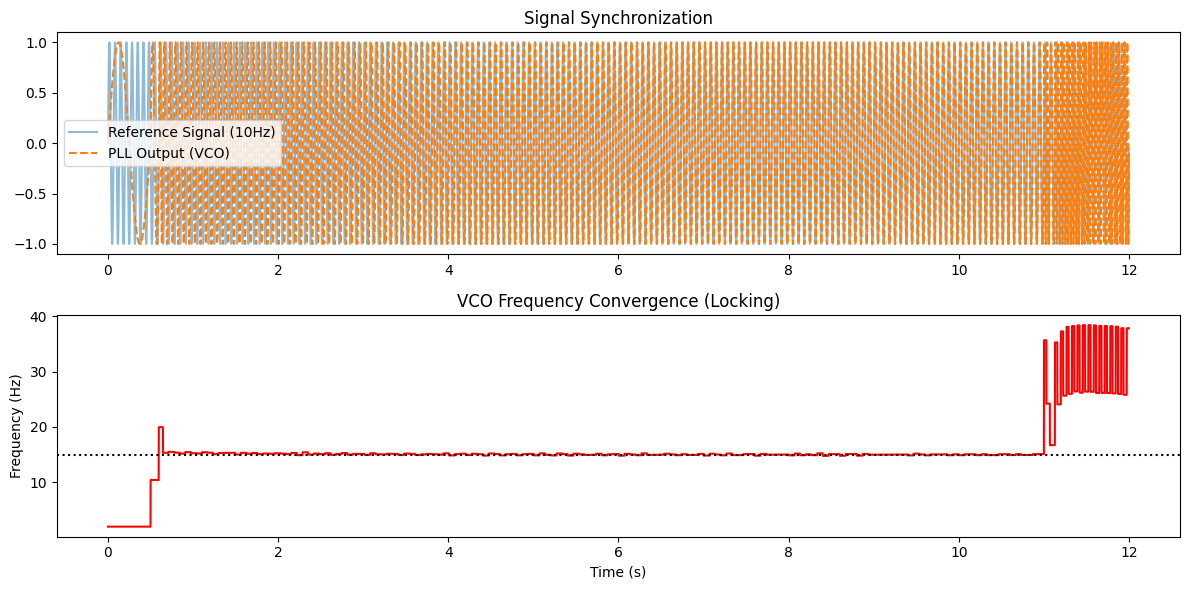

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_period_pll2(ref_freq, local_freq_init, fs, duration):
    t = np.arange(0, duration, 1/fs)  # compute the time step based on sampling rate fs
    n = len(t)                        # compute sample number
    
    # reference Signals
    ref_phase = 0.0                   # add a phase to the reference signal
    ref_sig = np.sin(2 * np.pi * ref_freq * t + ref_phase)

    # log values
    vco_sig = np.zeros(n)
    inst_freq = np.zeros(n)
    log_error = []

    current_phase = 0.0
    integral_error = 0.0
    
    # PI Gains for timing error
    Kp = 300.8
    Ki = 10.5

    for i in range(n):
        # 1. Generate local VCO signal
        vco_sig[i] = np.sin(current_phase)
        dt = t[i-1] - t[i]
        
        # 2. Detect Rising Edges (Zero-crossings)
        # Reference edge detection
        if ref_sig[i-1] < 0 and ref_sig[i] >= 0:
            t_ref_edge = t[i]
            
                 
        # VCO edge detection
        if vco_sig[i-1] < 0 and vco_sig[i] >= 0:
            t_vco_edge = t[i]

            # 3. Calculate Error based on period timing
            # You would think that which is WRONG:
            # If t_ref_edge > t_vco_edge, VCO is leading (too fast)
            # If t_ref_edge < t_vco_edge, VCO is lagging (too slow)
            # however, this will only return positive numbers since this instance is always leading the reference edge
            timing_error = t_vco_edge - t_ref_edge
            log_error.append(timing_error)
            
            # 4. PI Controller update
            integral_error += timing_error
            #integral_error = wrap_value(integral_error, T_vco)
            control_output = (Kp * timing_error) + (Ki * integral_error)
            
            # Update base frequency (clamped to prevent negative freq)
            local_freq_init = max(0.1, control_output)
        
        # 5. Update VCO Phase
        inst_freq[i] = local_freq_init
        current_phase += 2 * np.pi * local_freq_init / fs
        
    return t, ref_sig, vco_sig, inst_freq, log_error

# Simulation
fs = 2000
ref_freq = 15
base_freq = 2.0
duration = 12.0
t, ref, vco, freqs, errors = simulate_period_pll2(ref_freq, base_freq, fs, duration)

# Plotting results
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, ref, label='Reference Signal (10Hz)', alpha=0.5)
plt.plot(t, vco, label='PLL Output (VCO)', linestyle='--')
plt.title("Signal Synchronization")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, freqs, color='red')
plt.axhline(y=ref_freq, color='black', linestyle=':', label='Target Freq')
plt.title("VCO Frequency Convergence (Locking)")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

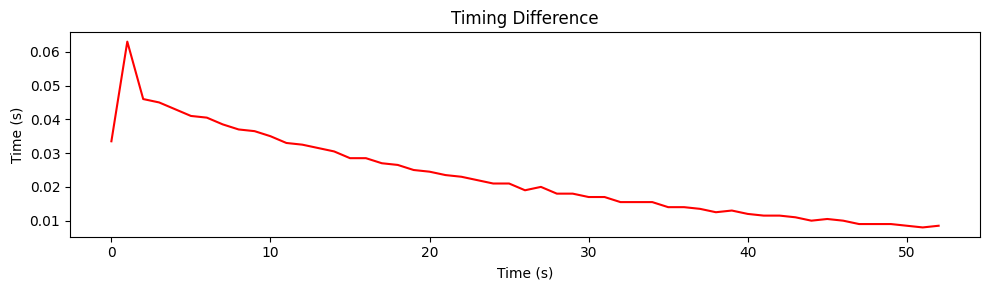

In [220]:
plt.figure(figsize=(10, 3))
plt.plot(errors, color='red')
plt.title("Timing Difference")
plt.ylabel("Time (s)")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

# Wrapped Time

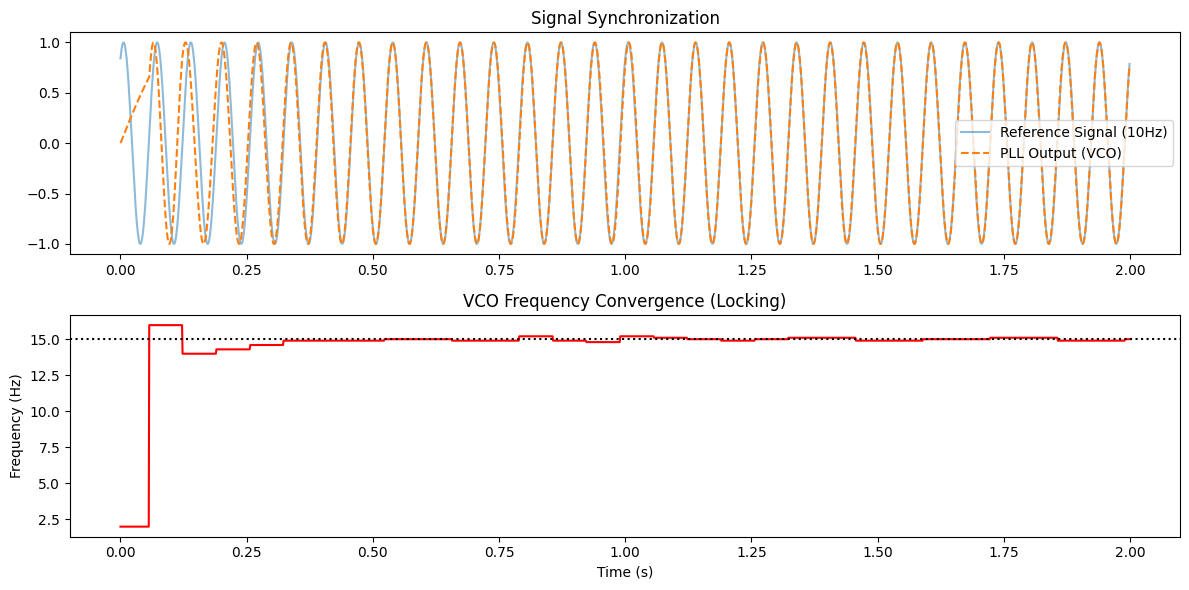

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_value(v, min_val, max_val):
    range_ = max_val - min_val
    return (v - min_val) % range_ + min_val

def simulate_period_pll2(ref_freq, local_freq_init, fs, duration):
    t = np.arange(0, duration, 1/fs)  # compute the time step based on sampling rate fs
    n = len(t)                        # compute sample number
    T_ref = 1./ref_freq
    
    # reference Signals
    ref_phase = 1.0                   # add a phase to the reference signal
    ref_sig = np.sin(2 * np.pi * ref_freq * t + ref_phase)

    # log values
    vco_sig = np.zeros(n)
    inst_freq = []
    log_error = []

    current_phase = 0.0
    integral_error = 0.0

    t_ref_edge = 0.0
    t_vco_edge = 0.0
    t_ref_previous_edge = 0.0
    t_vco_previous_edge = 0.0

    T_vco = 1/ref_freq

    control_output = local_freq_init
    
    # PI Gains for timing error
    Kp = 100.8
    Ki = 0.05

    for i in range(n):
        # 1. Generate local VCO signal
        vco_sig[i] = np.sin(current_phase)
        dt = t[i-1] - t[i]
        
        # 2. Detect Rising Edges (Zero-crossings)
        # Reference edge detection
        if ref_sig[i-1] < 0 and ref_sig[i] >= 0:
            t_ref_edge = t[i]
            T_ref = t_ref_edge - t_ref_previous_edge
            t_ref_previous_edge = t_ref_edge

            # 3. Calculate Error based on period timing
            timing_error = (t_vco_edge - t_ref_edge) 
            timing_error = wrap_value(timing_error, -T_vco/2., T_vco/2.)
            log_error.append(timing_error)
            
            # 4. PI Controller update
            integral_error += timing_error 
            control_output = ref_freq + (Kp * timing_error) + (Ki * integral_error)
        inst_freq.append(control_output)
                 
        # VCO edge detection
        if vco_sig[i-1] < 0 and vco_sig[i] >= 0:
            t_vco_edge = t[i]
            T_meas_vco = t_vco_edge - t_vco_previous_edge
            T_vco = T_meas_vco
            t_vco_previous_edge = t_vco_edge

        # 5. Update VCO Phase
        current_phase += 2 * np.pi * control_output / fs
        
    return t, ref_sig, vco_sig, inst_freq, log_error

# Simulation
fs = 1000
ref_freq = 15
base_freq = 2.0
duration = 2.0
t, ref, vco, freqs, errors = simulate_period_pll2(ref_freq, base_freq, fs, duration)

# Plotting results
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, ref, label='Reference Signal (10Hz)', alpha=0.5)
plt.plot(t, vco, label='PLL Output (VCO)', linestyle='--')
plt.title("Signal Synchronization")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, freqs, color='red')
plt.axhline(y=ref_freq, color='black', linestyle=':', label='Target Freq')
plt.title("VCO Frequency Convergence (Locking)")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

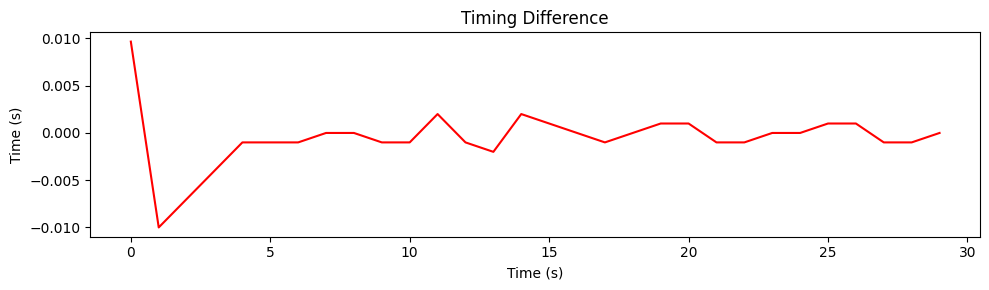

In [2]:
plt.figure(figsize=(10, 3))
plt.plot(errors, color='red')
plt.title("Timing Difference")
plt.ylabel("Time (s)")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

# Using Period

Since the control goes out of control with time difference, we use period insteads which represents better the phase difference between the 2 waves.

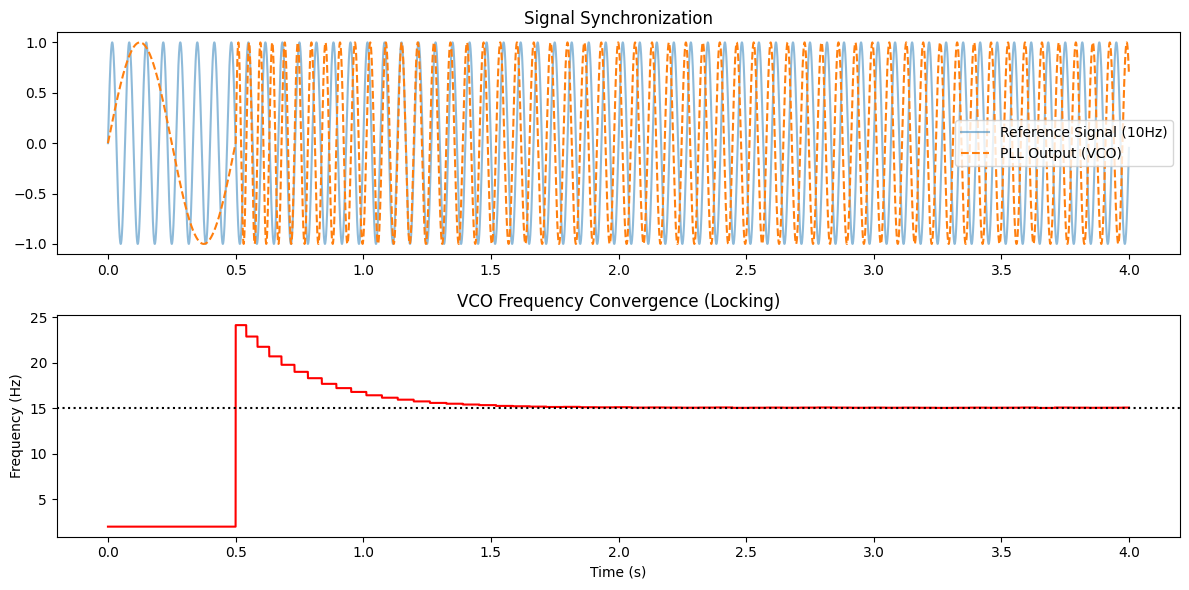

In [298]:
import numpy as np
import matplotlib.pyplot as plt
import math

def simulate_period_pll(ref_freq, local_freq_init, fs, duration):
    t = np.arange(0, duration, 1/fs)
    n = len(t)
    
    # reference Signals
    ref_phase = 0.0
    ref_sig = np.sin(2 * np.pi * ref_freq * t + ref_phase)

    # log values
    vco_sig = np.zeros(n)
    inst_freq = np.zeros(n)
    
    # PI Gains for timing error
    # Note: These scales differ from trig-based PLLs
    Kp = 50.9
    Ki = 0.05
    
    # State variables
    current_phase = 0.0
    integral_error = 0.0

    last_ref_edge = 0.0
    last_vco_edge = 0.0
    
    period_error = 0.0
    log_error = []

    control_output = local_freq_init

    for i in range(n):
        # 1. Generate local VCO signal
        vco_sig[i] = np.sin(current_phase)
        dt = t[i-1] - t[i]
        
        # 2. Detect Rising Edges (Zero-crossings)
        # Reference edge detection
        if ref_sig[i-1] < 0 and ref_sig[i] >= 0:
            T_ref = t[i] - last_ref_edge
            last_ref_edge = t[i]
                        
        # VCO edge detection
        if vco_sig[i-1] < 0 and vco_sig[i] >= 0:
            T_vco = t[i] - last_vco_edge
            last_vco_edge = t[i]
            
            # 3. Calculate Error based on period timing
            period_error = T_vco - T_ref
            log_error.append(period_error)

            # 4. PI Controller update
            integral_error += period_error
            control_output +=(Kp * period_error) + (Ki * integral_error)
            
            # Update base frequency (clamped to prevent negative freq)
            # control_output = max(0.1, control_output)
            
        # 5. Update VCO Phase
        inst_freq[i] = control_output
        current_phase += 2 * np.pi * control_output / fs
        
    return t, ref_sig, vco_sig, inst_freq, log_error

# Simulation
fs = 2000
ref_freq = 15
base_freq = 2.0
duration = 4.0
t, ref, vco, freqs, errors = simulate_period_pll(ref_freq, base_freq, fs, duration)

# Plotting results
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, ref, label='Reference Signal (10Hz)', alpha=0.5)
plt.plot(t, vco, label='PLL Output (VCO)', linestyle='--')
plt.title("Signal Synchronization")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, freqs, color='red')
plt.axhline(y=ref_freq, color='black', linestyle=':', label='Target Freq')
plt.title("VCO Frequency Convergence (Locking)")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

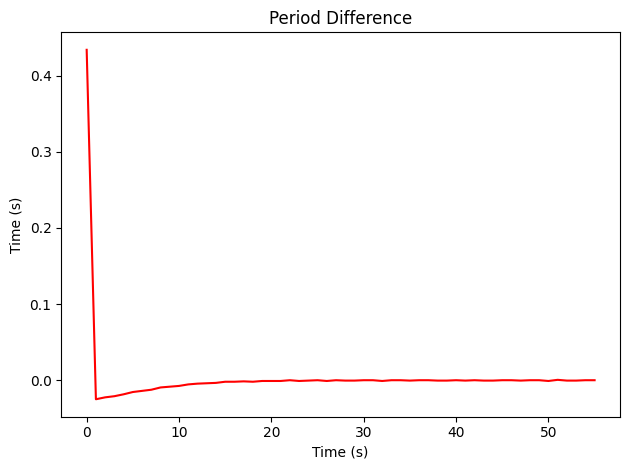

In [299]:
plt.plot(errors, color='red')
plt.title("Period Difference")
plt.ylabel("Time (s)")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

Observations:
 - the convergence is very slow (still not good after 8s)
 - the frequency atteints the reference but not the wave is not in phase with the reference. This is normal since we only measure the periode difference but not the phase difference.

# Dual Logic

For the previous examples, the input of vco is the same as the reference, so we can use directly the phrase command to control vco. But this is not the case for the real systems. So we need another control for the vco based on the phase command.

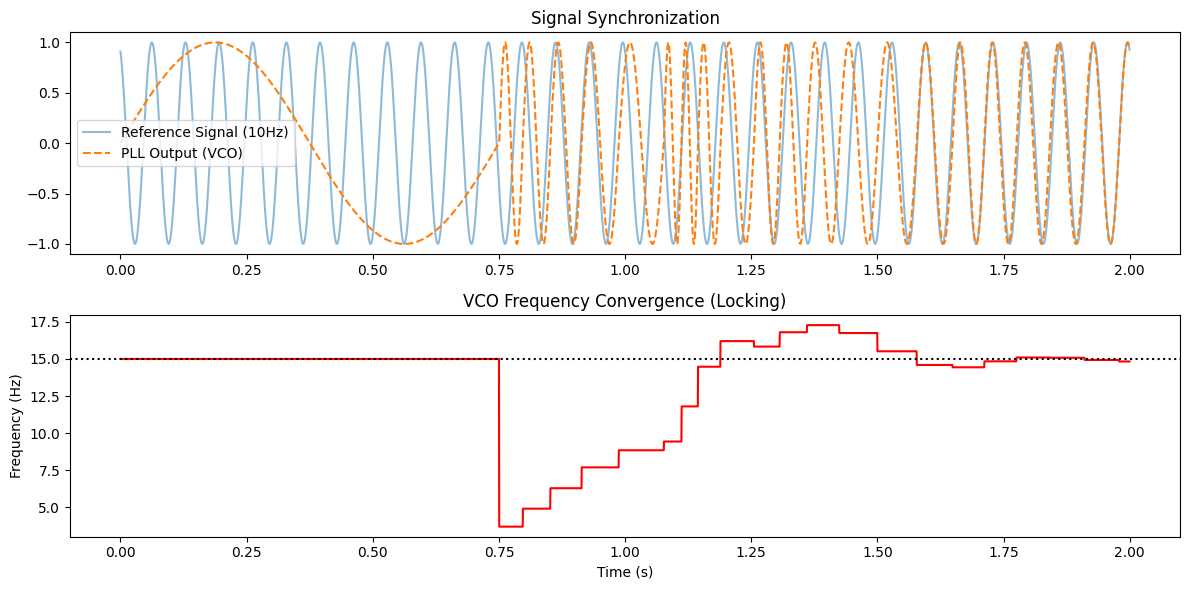

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_value(v, min_val, max_val):
    range_ = max_val - min_val
    return (v - min_val) % range_ + min_val

def vco(phase):
    return np.sin(phase / 1.5) #- np.sign(np.cos(phase)) /20

def simulate_dual_pll(ref_freq, local_freq_init, fs, duration):
    t = np.arange(0, duration, 1/fs)  # compute the time step based on sampling rate fs
    n = len(t)                        # compute sample number
    T_ref = 1./ref_freq
    
    # reference Signals
    ref_phase = 2.0                   # add a phase to the reference signal
    ref_sig = np.sin(2 * np.pi * ref_freq * t + ref_phase)

    # log values
    vco_sig = np.zeros(n)
    inst_freq = []
    log_error = []

    current_phase = 0.0
    int_err_timing = 0.0
    int_err_freq = 0.0

    t_ref_edge = 0.0
    t_vco_edge = 0.0
    t_ref_previous_edge = 0.0
    t_vco_previous_edge = 0.0

    T_vco = 1/ref_freq

    freq_control = local_freq_init
    vco_control = local_freq_init
    
    # PI Gains for timing error
    Kp_ref = 7.6
    Ki_ref = 6.3
    Kp_vco = 1.4
    Ki_vco = 0.6

    alpha = 0.3

    for i in range(n):
        # 1. Generate local VCO signal
        vco_sig[i] = vco(current_phase)
        dt = t[i-1] - t[i]
        
        # 2. Detect Rising Edges (Zero-crossings)
        # Reference edge detection
        if ref_sig[i-1] < 0 and ref_sig[i] >= 0:
            t_ref_edge = t[i]
            T_ref_meas = t_ref_edge - t_ref_previous_edge
            T_ref += alpha * (T_ref_meas - T_ref)
            t_ref_previous_edge = t_ref_edge

            # 3. Calculate Error based on period timing
            timing_error = (t_vco_edge - t_ref_edge) 
            timing_error = wrap_value(timing_error, -T_vco/2., T_vco/2.)
            log_error.append(timing_error)
            
            # 4. PI Controller update
            int_err_timing += timing_error * T_ref

            inv_T_ref = 1.0 / (T_ref)
            freq_control = ref_freq + (Kp_ref * timing_error * inv_T_ref) + (Ki_ref * int_err_timing * inv_T_ref)
        
                 
        # VCO edge detection
        if vco_sig[i-1] < 0 and vco_sig[i] >= 0:
            t_vco_edge = t[i]
            T_vco_meas = (t_vco_edge - t_vco_previous_edge)
            T_vco += alpha * (T_vco_meas - T_vco)
            t_vco_previous_edge = t_vco_edge

            freq_vco = 1.0 / T_vco
            freq_error = freq_control - freq_vco
            int_err_freq += freq_error 

            inv_T_vco = 1.0 / (T_vco)
            vco_control = local_freq_init + (Kp_vco * freq_error) + (Ki_vco * int_err_freq)
        
        # 5. Update VCO Phase
        current_phase += 2 * np.pi * vco_control / fs

        inst_freq.append(1./T_vco)
        
    return t, ref_sig, vco_sig, inst_freq, log_error

# Simulation
fs = 2000
ref_freq = 15
base_freq = 2.0
duration = 2.0
t, ref, vco, freqs, errors = simulate_dual_pll(ref_freq, base_freq, fs, duration)

# Plotting results
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, ref, label='Reference Signal (10Hz)', alpha=0.5)
plt.plot(t, vco, label='PLL Output (VCO)', linestyle='--')
plt.title("Signal Synchronization")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, freqs, color='red')
plt.axhline(y=ref_freq, color='black', linestyle=':', label='Target Freq')
plt.title("VCO Frequency Convergence (Locking)")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()